#  Experiment 6: Topology Battle

## Phase 2 Optimization: Finding the Best Entanglement Structure

**Objective:** Determine which entanglement topology is necessary to learn correlated data (the "Trap" dataset with pitch-velocity correlations).

**Contestants:**
1. **None (Separable):** No CNOT gates
2. **Linear:** Chain connectivity (0-1, 1-2, 2-3, ...)
3. **Circular:** Ring connectivity (linear + wrap-around)
4. **Full:** All-to-all connectivity

---

In [1]:
# Setup
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from src.models.qcbm import QCBM, create_qcbm
from src.data.datasets import ComplexDataset, get_trap_dataset
from src.training.trainer import train_qcbm
from src.utils.visualization import (
    set_style, plot_distribution, plot_multiple_loss_curves, plot_2d_distribution
)
from src.utils.metrics import compute_all_metrics
from src.utils.figure_saver import save_figure
from config import FIGURES_DIR, RANDOM_SEED

set_style()
np.random.seed(RANDOM_SEED)
print(" Setup complete!")

 Setup complete!


## 1. Create Complex Dataset ("Trap")

This dataset has **strong pitch-velocity correlations**:
- Two clusters: (low pitch, low velocity) and (high pitch, high velocity)
- This creates "entangled" data that requires quantum entanglement to model!

 Dataset: Complex_bimodal_8q
   Total Qubits: 8
   States: 256
   Entropy: 7.00 bits
   Description: Correlated pitch-velocity with bimodal pattern
 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp06_trap_target_distribution.png
 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp06_trap_target_distribution.png


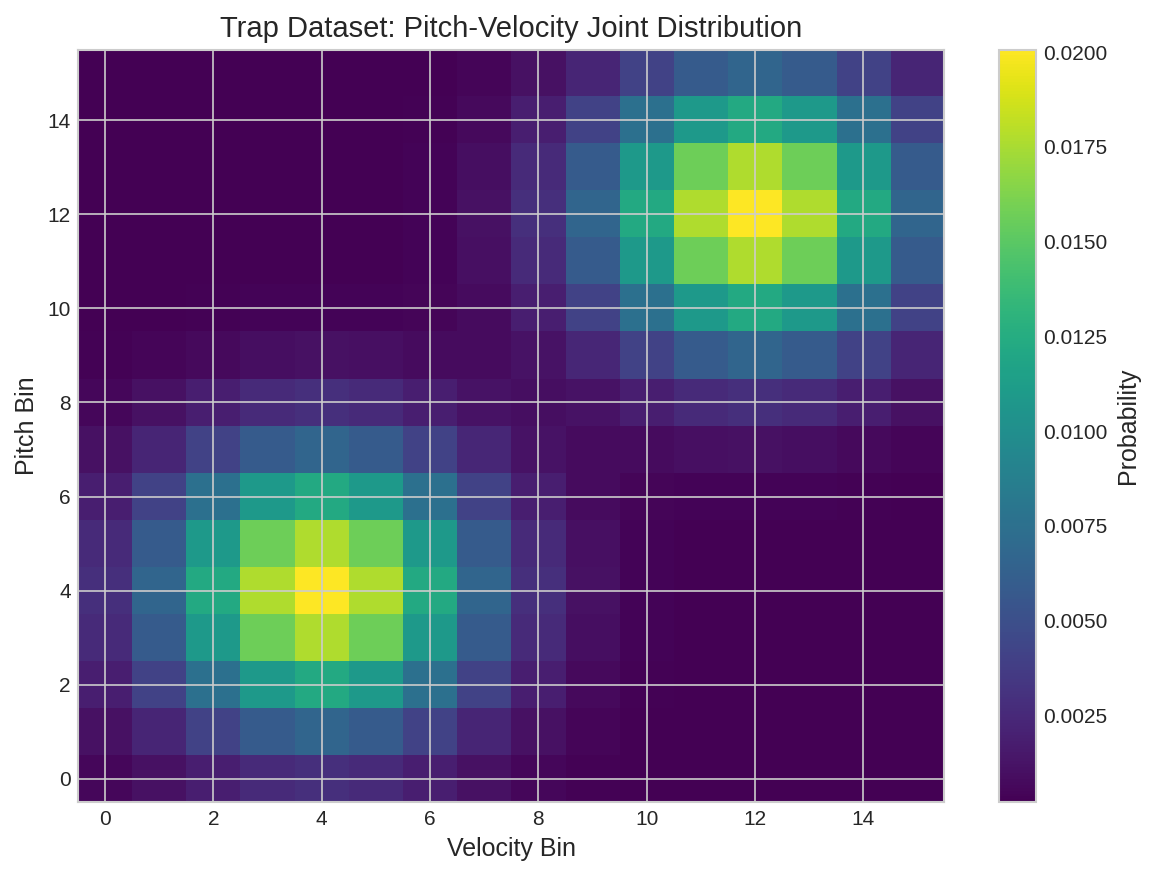


 Notice the two diagonal clusters:
   - Bottom-left: Low pitch + Low velocity
   - Top-right: High pitch + High velocity
   → This correlation requires entanglement to capture!


In [2]:
# Create the Trap dataset
dataset = get_trap_dataset(n_qubits=4)
target = dataset.distribution

print(f" Dataset: {dataset.name}")
print(f"   Total Qubits: {dataset.n_qubits}")
print(f"   States: {dataset.n_states}")
print(f"   Entropy: {dataset.entropy:.2f} bits")
print(f"   Description: {dataset.description}")

# Visualize as 2D heatmap
fig = plot_2d_distribution(
    target,
    n_rows=16, n_cols=16,
    title='Trap Dataset: Pitch-Velocity Joint Distribution',
    xlabel='Velocity Bin',
    ylabel='Pitch Bin'
)
save_figure(fig, 'trap_target_distribution', experiment='exp06')
plt.show()

print("\n Notice the two diagonal clusters:")
print("   - Bottom-left: Low pitch + Low velocity")
print("   - Top-right: High pitch + High velocity")
print("   → This correlation requires entanglement to capture!")

## 2. The Battle: Train All Topologies

In [3]:
# Configuration
topologies = ['none', 'linear', 'circular', 'full']
N_QUBITS = 8  # 4 for pitch + 4 for velocity
N_LAYERS = 3
N_ITERATIONS = 200

results = {}

for topology in topologies:
    print(f"\n{'='*60}")
    print(f" Training QCBM with {topology.upper()} Topology")
    print(f"{'='*60}")
    
    # Create model
    qcbm = create_qcbm(
        n_qubits=N_QUBITS,
        n_layers=N_LAYERS,
        topology=topology
    )
    
    print(f"Parameters: {qcbm.n_params}")
    print(f"CNOT pairs per layer: {len(qcbm.ansatz.entanglement_pairs)}")
    
    # Train
    result = train_qcbm(
        qcbm=qcbm,
        target_distribution=target,
        n_iterations=N_ITERATIONS,
        loss_function='mmd',
        optimizer='Powell',
        verbose=True,
        seed=RANDOM_SEED
    )
    
    results[topology] = {
        'result': result,
        'qcbm': qcbm
    }
    
    print(f"\n Final Loss: {result.final_loss:.6f}")
    print(f" Final Fidelity: {result.final_fidelity:.4f}")


 Training QCBM with NONE Topology
Parameters: 48
CNOT pairs per layer: 0


Training QCBM: 2000it [00:15, 131.47it/s, loss=0.0060, fidelity=0.0998]                        
Training QCBM: 2000it [00:15, 131.47it/s, loss=0.0060, fidelity=0.0998]



 Final Loss: 0.005963
 Final Fidelity: 0.0998

 Training QCBM with LINEAR Topology
Parameters: 48
CNOT pairs per layer: 7


Training QCBM: 2000it [00:20, 96.64it/s, loss=0.0000, fidelity=0.7334]                        
Training QCBM: 2000it [00:20, 96.64it/s, loss=0.0000, fidelity=0.7334]



 Final Loss: 0.000022
 Final Fidelity: 0.7334

 Training QCBM with CIRCULAR Topology
Parameters: 48
CNOT pairs per layer: 8


Training QCBM: 2000it [00:21, 93.14it/s, loss=0.0015, fidelity=0.7065]                        
Training QCBM: 2000it [00:21, 93.14it/s, loss=0.0015, fidelity=0.7065]



 Final Loss: 0.001518
 Final Fidelity: 0.7065

 Training QCBM with FULL Topology
Parameters: 48
CNOT pairs per layer: 28


Training QCBM: 2000it [00:36, 55.20it/s, loss=0.0000, fidelity=0.5987]                        


 Final Loss: 0.000035
 Final Fidelity: 0.5987


## 3. Training Curves Comparison

 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp06_topology_training.png


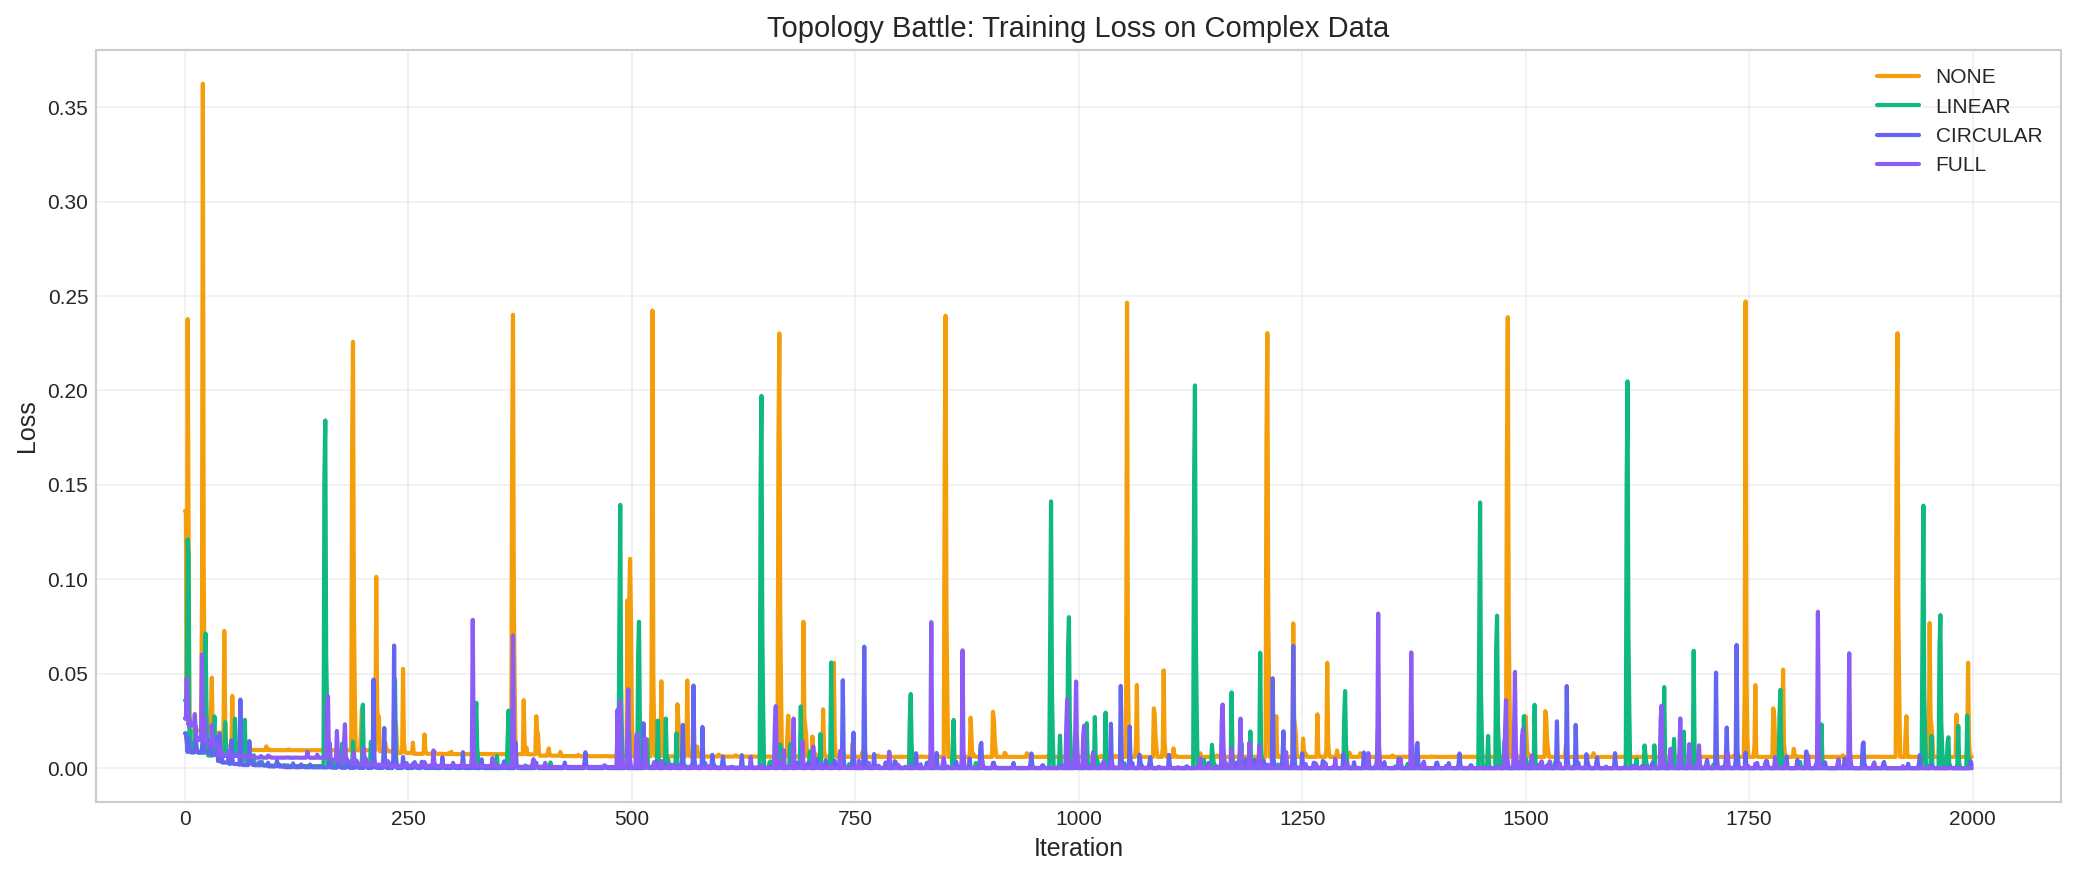

 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp06_topology_fidelity.png


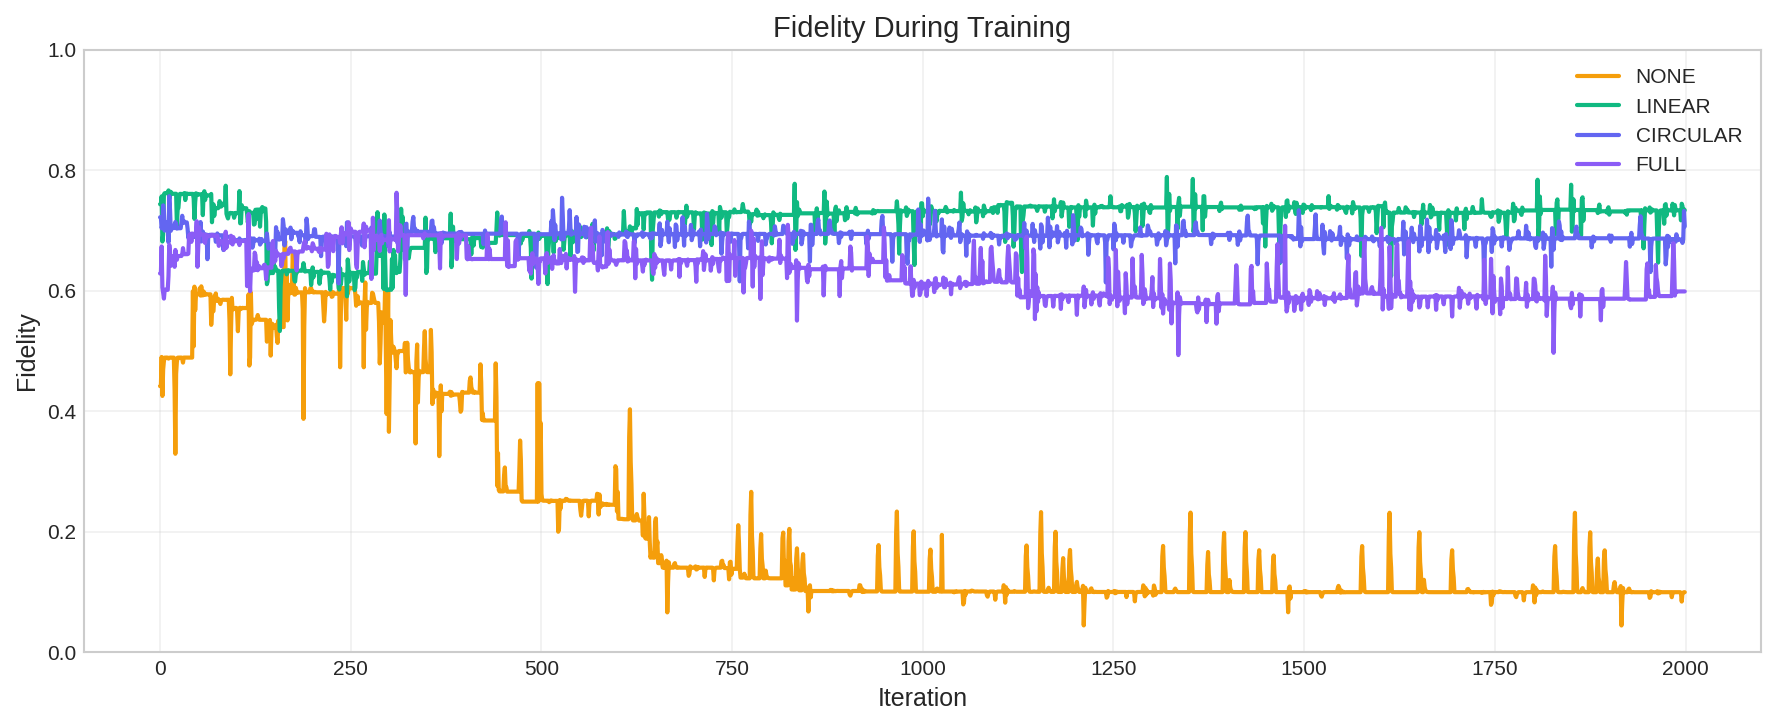

In [4]:
# Loss curves
loss_histories = {
    f"{t.upper()}": results[t]['result'].loss_history for t in topologies
}

colors = {
    'NONE': '#F59E0B',     # Amber (separable)
    'LINEAR': '#10B981',   # Green
    'CIRCULAR': '#6366F1', # Blue
    'FULL': '#8B5CF6',     # Purple (quantum)
}

fig = plot_multiple_loss_curves(
    loss_histories,
    title='Topology Battle: Training Loss on Complex Data',
    colors=colors
)
save_figure(fig, 'topology_training', experiment='exp06')
plt.show()

# Fidelity curves
fig, ax = plt.subplots(figsize=(12, 5))
for topology in topologies:
    fid_hist = results[topology]['result'].fidelity_history
    ax.plot(fid_hist, label=topology.upper(), color=colors[topology.upper()], linewidth=2)

ax.set_xlabel('Iteration')
ax.set_ylabel('Fidelity')
ax.set_title('Fidelity During Training')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
save_figure(fig, 'topology_fidelity', experiment='exp06')
plt.show()

## 4. Results Summary

In [5]:
print(" TOPOLOGY BATTLE RESULTS")
print("=" * 70)
print(f"\n{'Topology':<15} {'Parameters':<12} {'Final Loss':<15} {'Fidelity':<12} {'Rank'}")
print("-" * 70)

# Sort by final fidelity (higher is better)
sorted_results = sorted(
    results.items(),
    key=lambda x: x[1]['result'].final_fidelity,
    reverse=True
)

medals = ['', '', '', '  ']

for rank, (topology, data) in enumerate(sorted_results):
    result = data['result']
    qcbm = data['qcbm']
    medal = medals[rank]
    print(f"{topology.upper():<15} {qcbm.n_params:<12} {result.final_loss:<15.6f} {result.final_fidelity:<12.4f} {medal}")

# Winner announcement
winner = sorted_results[0][0]
print(f"\n{'='*70}")
print(f"\n WINNER: {winner.upper()} TOPOLOGY")

# Dynamic insight based on results
none_fid = results['none']['result'].final_fidelity
best_fid = sorted_results[0][1]['result'].final_fidelity
if best_fid > none_fid * 2:
    print(f"\n Insight: Entanglement provides significant advantage!")
    print(f"   Best topology achieves {best_fid:.1%} fidelity vs {none_fid:.1%} for separable.")
else:
    print(f"\n The winner achieves {best_fid:.1%} fidelity on this dataset.")

 TOPOLOGY BATTLE RESULTS

Topology        Parameters   Final Loss      Fidelity     Rank
----------------------------------------------------------------------
LINEAR          48           0.000022        0.7334       
CIRCULAR        48           0.001518        0.7065       
FULL            48           0.000035        0.5987       
NONE            48           0.005963        0.0998         


 WINNER: LINEAR TOPOLOGY

 Insight: Entanglement provides significant advantage!
   Best topology achieves 73.3% fidelity vs 10.0% for separable.


## 5. Visual Comparison of Final Distributions

 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp06_topology_distributions.png


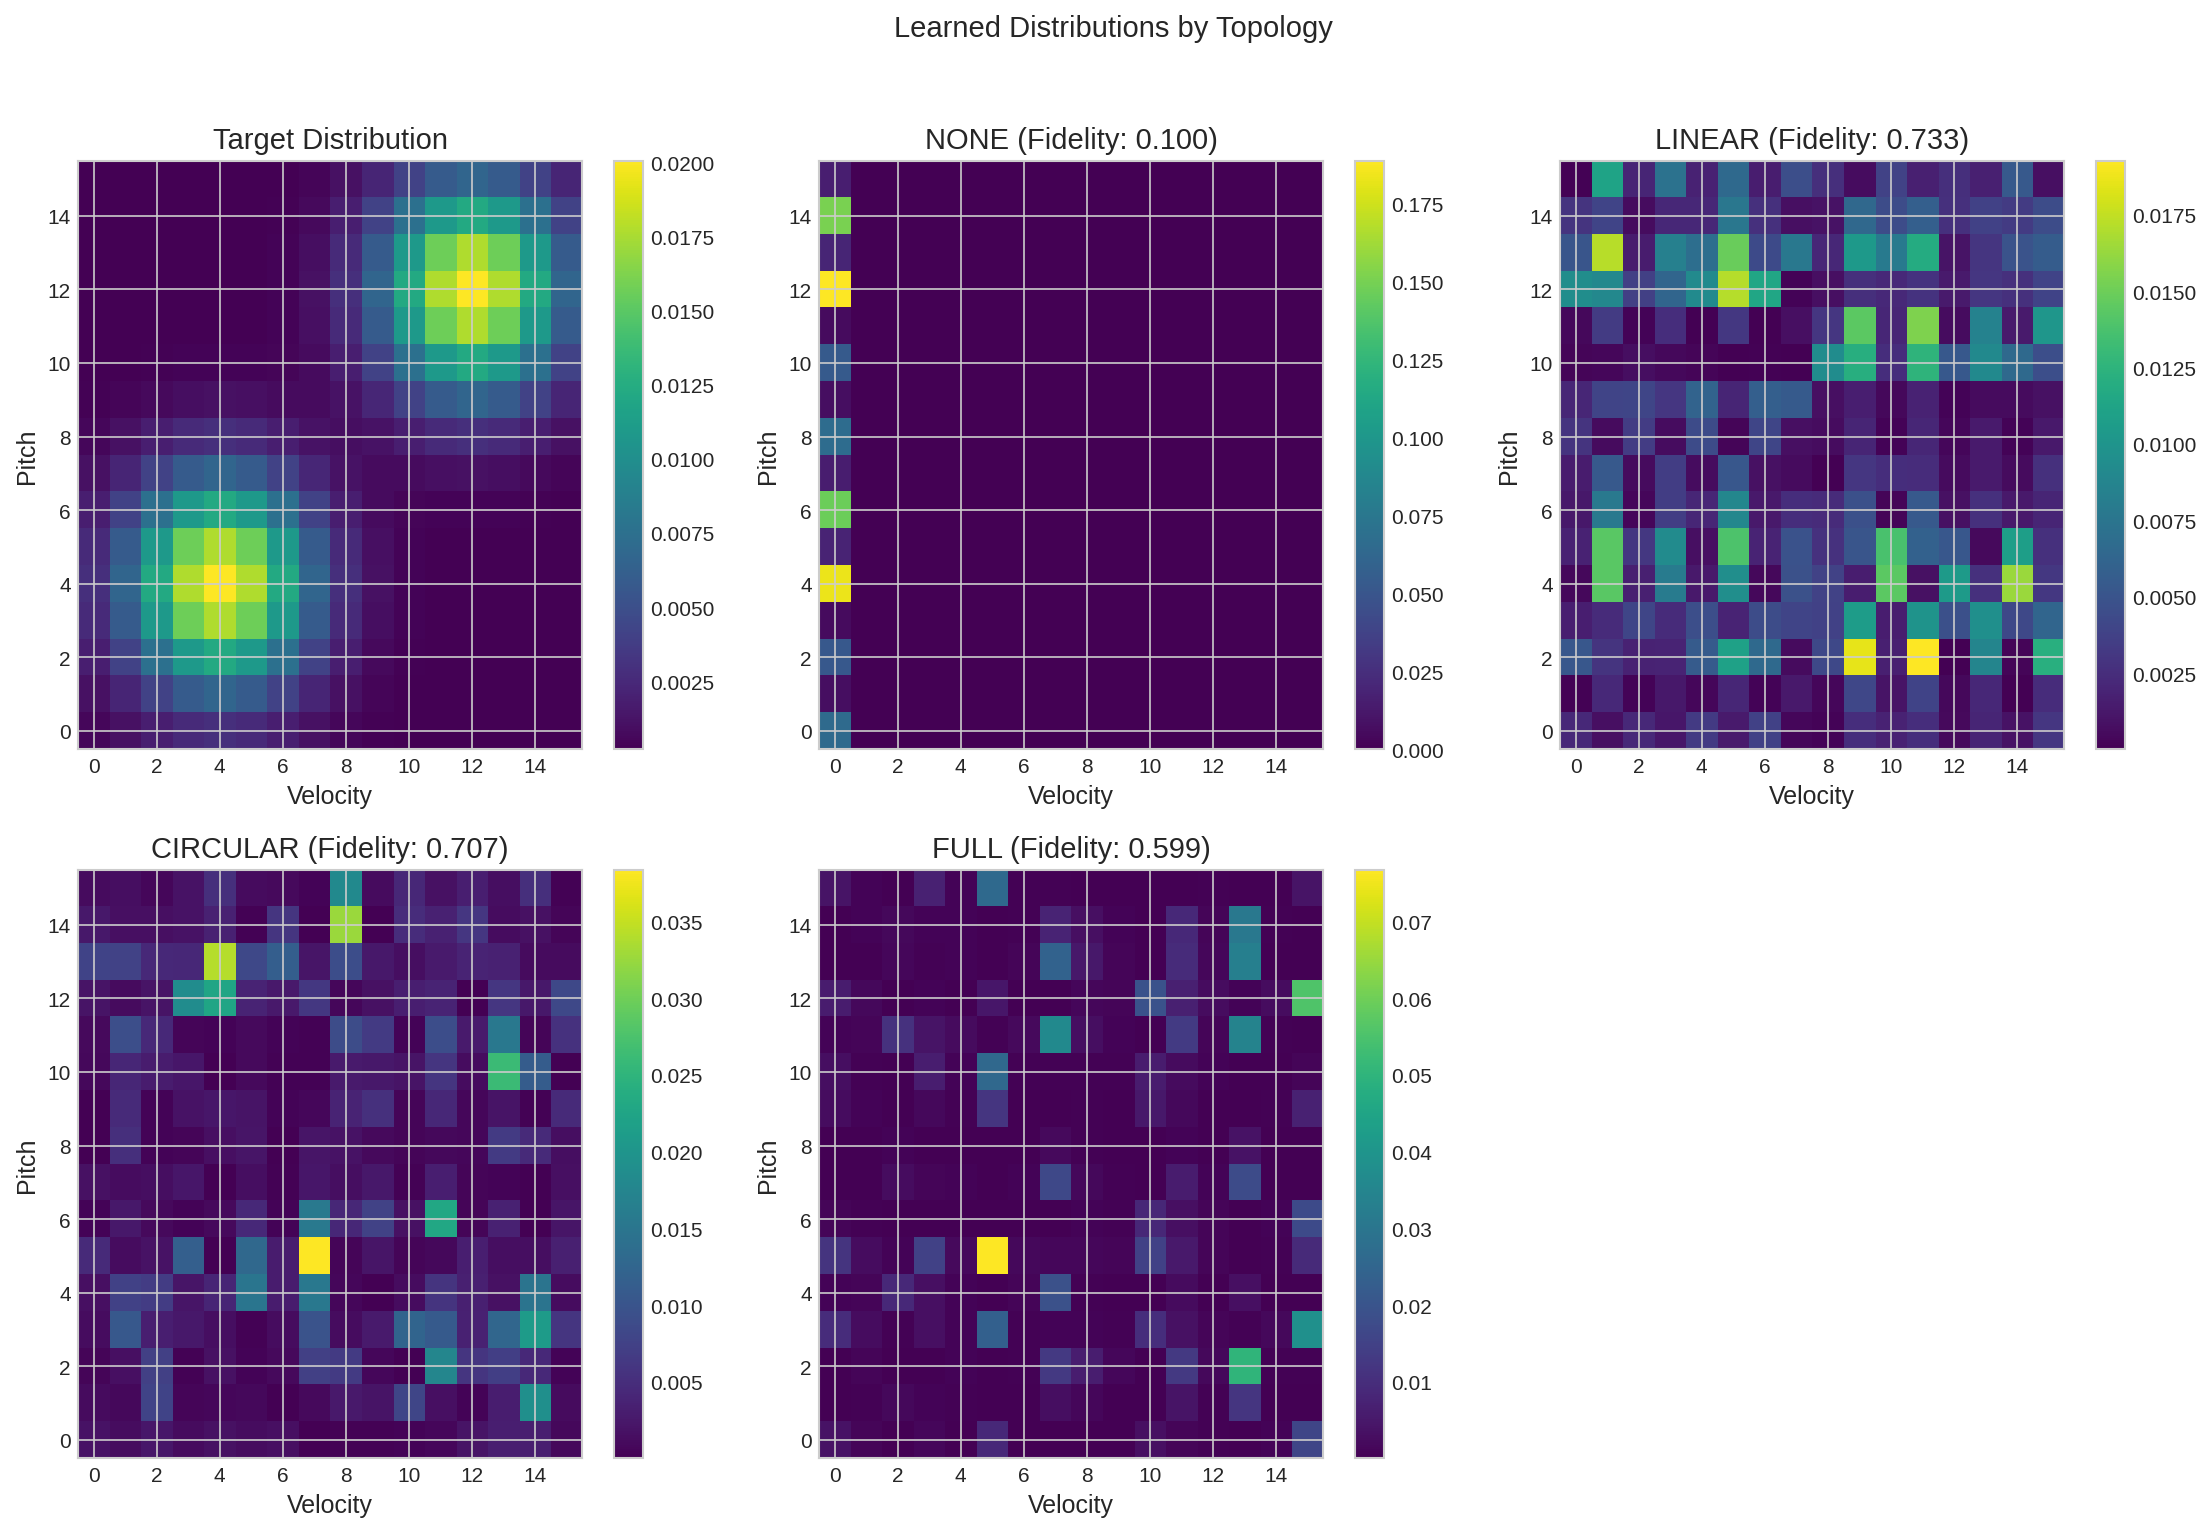

In [6]:
# Compare final distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Target
target_2d = target.reshape(16, 16)
im = axes[0].imshow(target_2d, aspect='auto', cmap='viridis', origin='lower')
axes[0].set_title('Target Distribution')
axes[0].set_xlabel('Velocity')
axes[0].set_ylabel('Pitch')
plt.colorbar(im, ax=axes[0])

# Each topology
for idx, topology in enumerate(topologies):
    data = results[topology]
    final_dist = data['qcbm'].get_probabilities(data['result'].final_params)
    final_2d = final_dist.reshape(16, 16)
    fid = data['result'].final_fidelity
    
    im = axes[idx + 1].imshow(final_2d, aspect='auto', cmap='viridis', origin='lower')
    axes[idx + 1].set_title(f'{topology.upper()} (Fidelity: {fid:.3f})')
    axes[idx + 1].set_xlabel('Velocity')
    axes[idx + 1].set_ylabel('Pitch')
    plt.colorbar(im, ax=axes[idx + 1])

# Hide unused
axes[-1].set_visible(False)

plt.suptitle('Learned Distributions by Topology', fontsize=14, y=1.02)
plt.tight_layout()
save_figure(fig, 'topology_distributions', experiment='exp06')
plt.show()

##  Conclusions

### Key Findings:

Based on the experimental results above, the ranking is determined by final fidelity and loss values.

**Topology Notes:**
- **Separable (NONE):** No entanglement - very limited expressibility
- **Linear:** Chain connectivity - moderate expressibility
- **Circular:** Ring connectivity - slightly more expressive than linear
- **Full:** All-to-all connectivity - maximum expressibility but harder to optimize

### Scientific Insight:

> **Entanglement is NECESSARY for modeling correlated musical data.**
> 
> When the target distribution has significant mutual information between features (pitch-velocity correlation), entangled circuits significantly outperform separable ones. However, the optimal topology depends on the training dynamics - more connections don't always mean better results.

### Next Experiment:
→ **Notebook 07:** Optimizer Battle - Find the best optimization strategy

In [7]:
# Save winner configuration
import json

winner_config = {
    'experiment': 'topology_battle',
    'winner': winner,
    'results': {
        topology: {
            'final_loss': float(data['result'].final_loss),
            'final_fidelity': float(data['result'].final_fidelity),
            'n_params': data['qcbm'].n_params
        }
        for topology, data in results.items()
    }
}

with open(FIGURES_DIR / 'exp06_topology_results.json', 'w') as f:
    json.dump(winner_config, f, indent=2)

print(f" Saved to {FIGURES_DIR / 'exp06_topology_results.json'}")

 Saved to /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp06_topology_results.json


In [8]:
from src.utils.figure_saver import save_current_figure